# Visualitation of top candidates for VGFR2
In this notebook we use the results of our Nextflow pipeline (`top_candidates_master.csv`) and will use RDKit to generate a 2D representation of our top candidates and py 3Dmol to represent the protein-ligand complex in 3D.

In [6]:
!pip install pandas rdkit

In [7]:
!pip install py3Dmol

We import the data using pandas and generating a Data Frame.

In [3]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
import os

# Define the path to the results
results_path = '../nextflow_pipeline/results/top_final/top_candidates_master.csv'

if not os.path.exists(results_path):
    print(f"Error: The file {results_path} was not found.")
else:
    # Load the dataframe
    df_results = pd.read_csv(results_path)
    print(f"Successfully loaded {len(df_results)} top candidates.\n")
    
    # Display the first 3 rows to verify data
    display(df_results.head(3))

Successfully loaded 50 top candidates.



,SMILES_ID,Vina_Affinity_kcal_mol,CNN_Pose_Score,CNN_Affinity_pKd,BBB_Martins,AMES_Toxicity,DILI_Risk,Carcinogens,Extracted_SMILES
0,LTS0172163,-11.75,0.6115,7.047,0.2575,0.4740,0.3989,NaN,[C]C1([C])[C][C]c2[c]c([C](O)[C]C(=O)c3[c]c4c(...
1,LTS0070549,-11.72,0.7130,7.415,0.3209,0.4575,0.4065,NaN,[C][C][C]([C])[C][C]([C])/[C]=C([C])/[C]=[C]/[...
2,LTS0100108,-11.68,0.6716,6.140,0.2372,0.0683,0.2107,NaN,[C]C1=C([C])C(=O)O[C]([C@]([C])(O)[C@]2(O)[C][...


## Generation of the molecular matrix
We extract the SMILES format of the 9 best molecules and render a vectorial image showing it's ID, classic affinityu and AI level of confidence. 

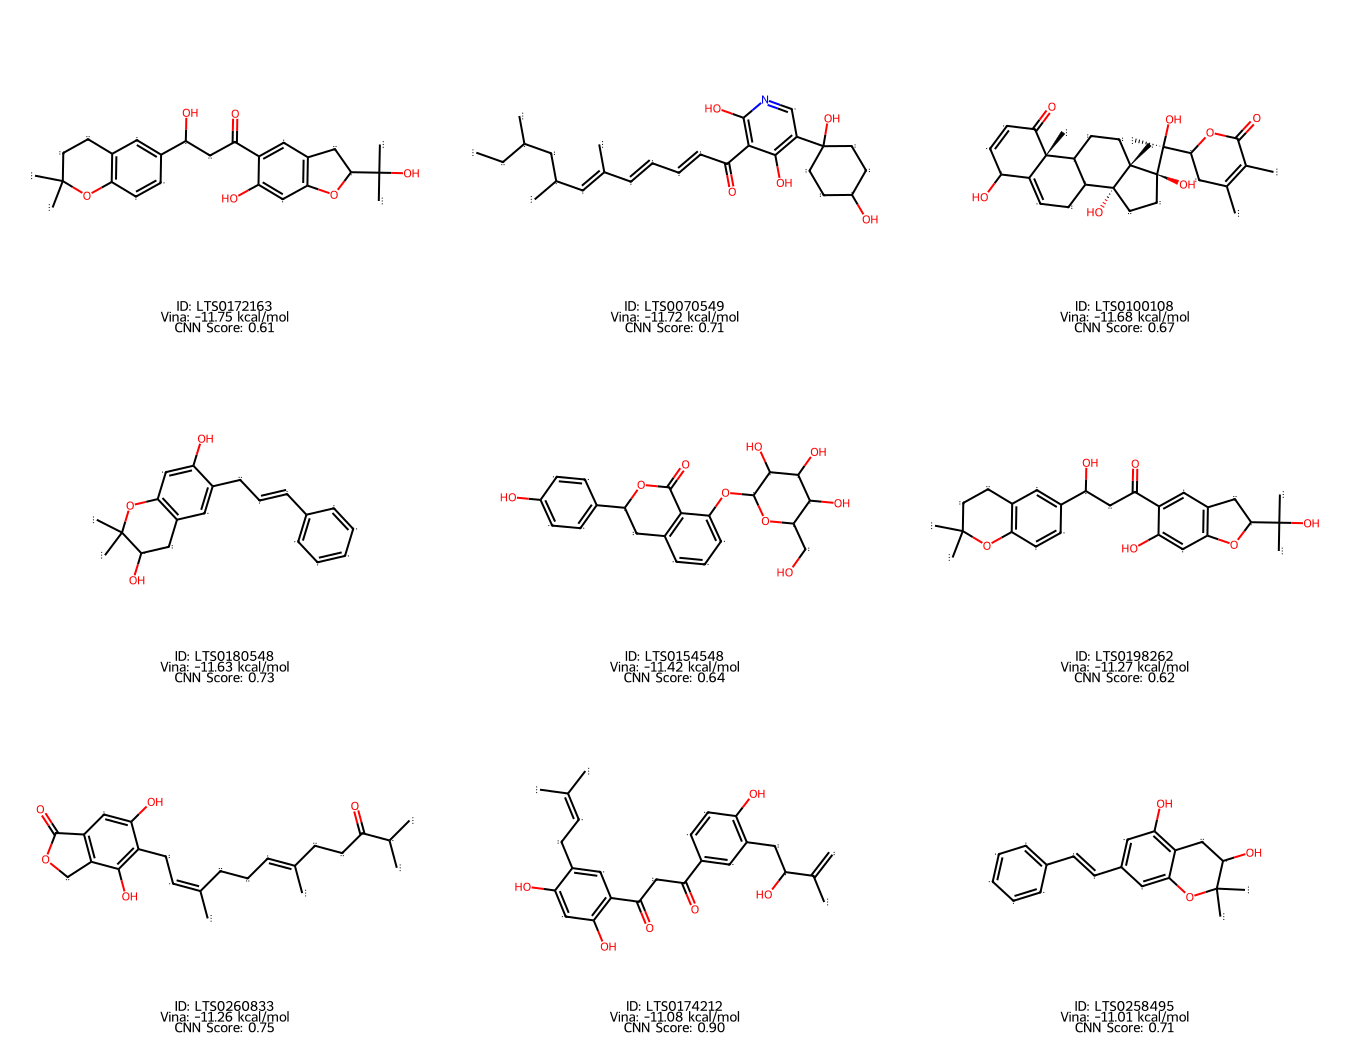

In [4]:
# Select the top 9 candidates
top_hits = df_results.head(9).copy()

molecule_list = []
molecule_legends = []

for index, row in top_hits.iterrows():
    smiles_string = row['Extracted_SMILES']
    mol = Chem.MolFromSmiles(smiles_string)
    
    if mol is not None:
        molecule_list.append(mol)
        
        # Create a descriptive legend
        legend = (
            f"ID: {row['SMILES_ID']}\n"
            f"Vina: {row['Vina_Affinity_kcal_mol']:.2f} kcal/mol\n"
            f"CNN Score: {row['CNN_Pose_Score']:.2f}"
        )
        molecule_legends.append(legend)

# Generate and display the grid image
grid_image = Draw.MolsToGridImage(
    molecule_list, 
    molsPerRow=3, 
    subImgSize=(450, 350), 
    legends=molecule_legends,
    useSVG=True
)

display(grid_image)

## 3D Representation of the protein-ligand complex
Using py3Dmol we represend the protein-ligand complex of the besta candidate.

In [14]:
import py3Dmol
import os

# importing the top candidate ID from the dataframe
top_candidate_id = top_hits.iloc[0]['SMILES_ID']

# Define file paths for the receptor and ligand
receptor_path = ('../raw_data/3VO3.pdb')
ligand_path = ('../results/top_final/top_poses/'f'{top_candidate_id}_docked.sdf')

# Reading the receptor and ligand files
with open(receptor_path, 'r') as f:
    receptor_content = f.read()
with open(ligand_path, 'r') as f:
    ligand_content = f.read()

# Create a 3D viewer
viewer = py3Dmol.view(width=800, height=500)

# Display as a light gray cartoon to highlight the secondary structure
# Add a semi-transparent Van der Waals (VDW) surface to visualize the pocket
viewer.addModel(receptor_content, 'pdb')
viewer.setStyle({'model': -1}, {'cartoon': {'color': 'lightgray'}})
viewer.addSurface(py3Dmol.VDW, {'opacity': 0.6, 'color': 'white'})

# Display as sticks using standard CPK coloring with green carbons
viewer.addModel(ligand_content, 'sdf')
viewer.setStyle({'model': -1}, {'stick': {'colorscheme': 'greenCarbon', 'radius': 0.2}})

# Focus the camera directly on the ligand to easily inspect the binding site
viewer.zoomTo({'model': 1})
    
print(f"\nSuccessfully loaded 3D complex: VGFR2 + {top_candidate_id}")
viewer.show()


Successfully loaded 3D complex: VGFR2 + LTS0070549


3Dmol.js failed to load for some reason. Please check your browser console for error messages.